# 04 Uncertainty and calibration

Reliability diagram and Expected Calibration Error (ECE).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.uncertainty.calibration import calibration_diagnostics

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(9)

/Users/macintosh/code/neural-spike-analysis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
T = 900
y_true = rng.normal(loc=0.0, scale=1.0, size=(T, 2))
base_std = 0.20 + 0.35 * np.abs(y_true)
noise = rng.normal(scale=base_std)
pred_mean = y_true + 0.7 * noise
pred_std = np.clip(base_std * (0.9 + 0.1 * rng.normal(size=base_std.shape)), 0.05, None)

result = calibration_diagnostics(
    pred_mean=pred_mean,
    pred_std=pred_std,
    y_true=y_true,
    confidence_levels=np.linspace(0.1, 0.9, 9),
    output_path='artifacts/reliability_diagram.png',
)
print(f'ECE: {result.ece:.4f}')

ECE: 0.0643


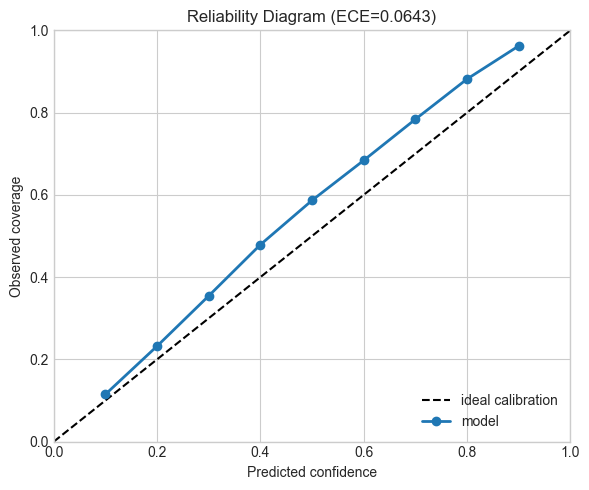

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='ideal calibration')
ax.plot(result.confidence_levels, result.observed_coverage, marker='o', linewidth=2, label='model')
ax.set_title(f'Reliability Diagram (ECE={result.ece:.4f})')
ax.set_xlabel('Predicted confidence')
ax.set_ylabel('Observed coverage')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
fig.tight_layout()